In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Annotated
from dotenv import load_dotenv
import os
from pydantic import BaseModel , Field
import operator

In [ ]:
from langchain_mistralai import ChatMistralAI
model = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.7,
    api_key = os.getenv("mistral_APIKEY")
)

load_dotenv()


The capital of France is **Paris**.


In [9]:
class EvaluationSchema(BaseModel):
    feedback: str= Field(description="Detailed feedback on the quality of the blog post, including strengths and areas for improvement.")
    score:int = Field(description="A score between 1 and 10 evaluating the overall quality of the blog post, with 10 being the highest.",ge=1 , le=10)
    

In [10]:
structured_model = model.with_structured_output(EvaluationSchema)

In [35]:
essay ="""The impact of technology on society it is very big and also bad, many peoples are always looking at there phones every single day, without looking at the road or people. For example my friend he always texts while walking, then he hit a pole yesterday, it was very funny but also dangerous. Because he could of got hurted bad.

Furthermore, social media make us lonely, because we don’t talk face to face no more we just send emojis, which is not real feelings. If you think about it, back in the days, people used to write letters and wait for weeks, now we get mad if someone don't reply in two seconds, this is a clear sign that patience is dead. Also identity theft is a huge issue online, hackers can steal your money, your photos, your whole life, just with one click.

In conclusion technology have advantages, like finding information fast, but the disadvantages are way more worse. We need to put down our screens, and enjoy nature, otherwise we will all become like robots who can't think for themselves anymore. """

In [12]:
prompt = f"Evaluate the quality of the following blog post about artificial intelligence and provide feedback for improvement:\n\n{essay}\n\nFeedback:"

In [15]:
structured_model.invoke(prompt).score

7

In [18]:
class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float

In [19]:
def evaluate_language(state:UPSCState) -> UPSCState:
    prompt = f"Evaluate the language quality of the following essay and provide feedback for improvement:\n\n{state['essay']}\n\nFeedback:"
    output = structured_model.invoke(prompt)
    return {"language_feedback": output.feedback , "individual_scores":[output.score]}

In [20]:
def evaluate_analysis(state:UPSCState) -> UPSCState:
    prompt = f"Evaluate the analysis quality of the following essay and provide feedback for improvement:\n\n{state['essay']}\n\nFeedback:"
    output = structured_model.invoke(prompt)
    return {"analysis_feedback": output.feedback , "individual_scores":[output.score]}

In [23]:
def evaluate_clarity(state:UPSCState) -> UPSCState:
    prompt = f"Evaluate the clarity of the following essay and provide feedback for improvement:\n\n{state['essay']}\n\nFeedback:"
    output = structured_model.invoke(prompt)
    return {"clarity_feedback": output.feedback , "individual_scores":[output.score]}

In [22]:
def final_evaluation(state:UPSCState) -> UPSCState:
    prompt = f"Based on the following feedback and scores, provide an overall evaluation of the essay, including an average score and suggestions for improvement:\n\nLanguage Feedback: {state['language_feedback']}\nAnalysis Feedback: {state['analysis_feedback']}\nClarity Feedback: {state['clarity_feedback']}\n"
    overall_feedback = model.invoke(prompt).content
    
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])
    return {"overall_feedback": overall_feedback , "avg_score": avg_score}
    

In [29]:
graph = StateGraph(UPSCState)
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity', 'final_evaluation')
graph.add_edge('final_evaluation', END)

workflow = graph.compile()

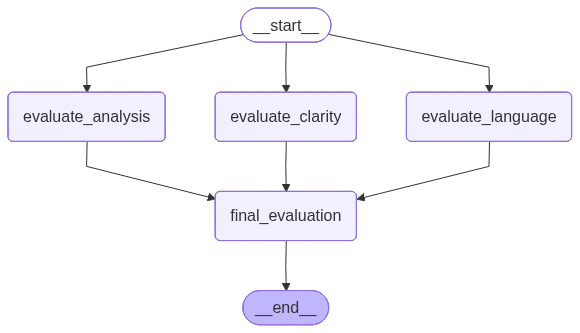

In [30]:
workflow

In [45]:
initial_state = {
    "essay": essay,
}
workflow.invoke(initial_state)

{'essay': "The impact of technology on society it is very big and also bad, many peoples are always looking at there phones every single day, without looking at the road or people. For example my friend he always texts while walking, then he hit a pole yesterday, it was very funny but also dangerous. Because he could of got hurted bad.\n\nFurthermore, social media make us lonely, because we don’t talk face to face no more we just send emojis, which is not real feelings. If you think about it, back in the days, people used to write letters and wait for weeks, now we get mad if someone don't reply in two seconds, this is a clear sign that patience is dead. Also identity theft is a huge issue online, hackers can steal your money, your photos, your whole life, just with one click.\n\nIn conclusion technology have advantages, like finding information fast, but the disadvantages are way more worse. We need to put down our screens, and enjoy nature, otherwise we will all become like robots wh